In [4]:
# %% Cell 1: Imports and setup
print("=== CELL 1 STARTING ===")
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Robust project-root detection (works in .py and .ipynb) ---
def _find_project_root(start: str) -> str:
    current = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(current, "src")):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            raise RuntimeError(f"Could not find project root above {start}")
        current = parent

try:
    _HERE = os.path.dirname(os.path.abspath(__file__))   # type: ignore[name-defined]
except NameError:
    _HERE = os.getcwd()
_HERE = str(_HERE)   # ensure it's a str, not Optional[str]

PROJECT_ROOT = _find_project_root(_HERE)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.config import ExperimentConfig
from src.environment.xl_mimo_env import XLMIMOEnv

FIG_DIR = os.path.join(_HERE, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("Imports OK")
print(f"Notebook dir:  {_HERE}")
print(f"Project root:  {PROJECT_ROOT}")
print(f"Figures saved: {FIG_DIR}")

=== CELL 1 STARTING ===
Imports OK
Notebook dir:  c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys\notebooks
Project root:  c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys
Figures saved: c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys\notebooks\figures


In [5]:
# %% Cell 2: Build environments from all configs
CONFIGS = {
    "default":  "configs/default.yaml",
    "exp1":     "configs/experiments/exp1_subarray.yaml",
    "exp2":     "configs/experiments/exp2_beam_selection.yaml",
}

envs = {}
cfgs = {}

for name, exp_path in CONFIGS.items():
    cfg = ExperimentConfig.from_yaml(
        default_path="configs/default.yaml",
        experiment_path=(exp_path if name != "default" else None),
    )
    env = XLMIMOEnv(config=cfg)
    envs[name] = env
    cfgs[name] = cfg
    print(f"[{name:8s}] antennas={env.num_antennas}, subs={env.num_subarrays}, "
          f"beams={env.num_beams}, users={env.num_users}, "
          f"obs_dim={env.observation_space.shape[0]}")

# Sanity: envs share antenna/subarray topology but may differ in
# users (and therefore observation dimension)
base = envs["default"]
for name, e in envs.items():
    assert e.num_antennas == base.num_antennas
    assert e.num_subarrays == base.num_subarrays
print("\nAll envs share the antenna/subarray topology (256 ant, 8 subs).")
print("Observation dims may vary with num_users:")
for name, e in envs.items():
    print(f"  {name}: obs_dim = {e.observation_space.shape[0]} "
          f"(users={e.num_users})")

[default ] antennas=256, subs=8, beams=61, users=4, obs_dim=26
[exp1    ] antennas=256, subs=8, beams=61, users=3, obs_dim=24
[exp2    ] antennas=256, subs=8, beams=21, users=4, obs_dim=26

All envs share the antenna/subarray topology (256 ant, 8 subs).
Observation dims may vary with num_users:
  default: obs_dim = 26 (users=4)
  exp1: obs_dim = 24 (users=3)
  exp2: obs_dim = 26 (users=4)


In [6]:
# %% Cell 3: Inspect a single reset
env = envs["default"]
obs, info = env.reset(seed=42)

print(f"Observation shape: {obs.shape}  dtype: {obs.dtype}")
print(f"Value range:      [{obs.min():.4f}, {obs.max():.4f}]")
print(f"All finite:       {bool(np.all(np.isfinite(obs)))}")
print(f"\nFirst 10 values:  {obs[:10].round(3)}")
print(f"Last 5 values:    {obs[-5:].round(3)}")
print(f"\nInfo keys:        {sorted(info.keys())}")

Observation shape: (26,)  dtype: float32
Value range:      [0.0000, 1.0000]
All finite:       True

First 10 values:  [1. 1. 1. 1. 0. 0. 0. 0. 1. 1.]
Last 5 values:    [1.    1.    1.    1.    0.122]

Info keys:        ['num_beams', 'num_subarrays', 'step']


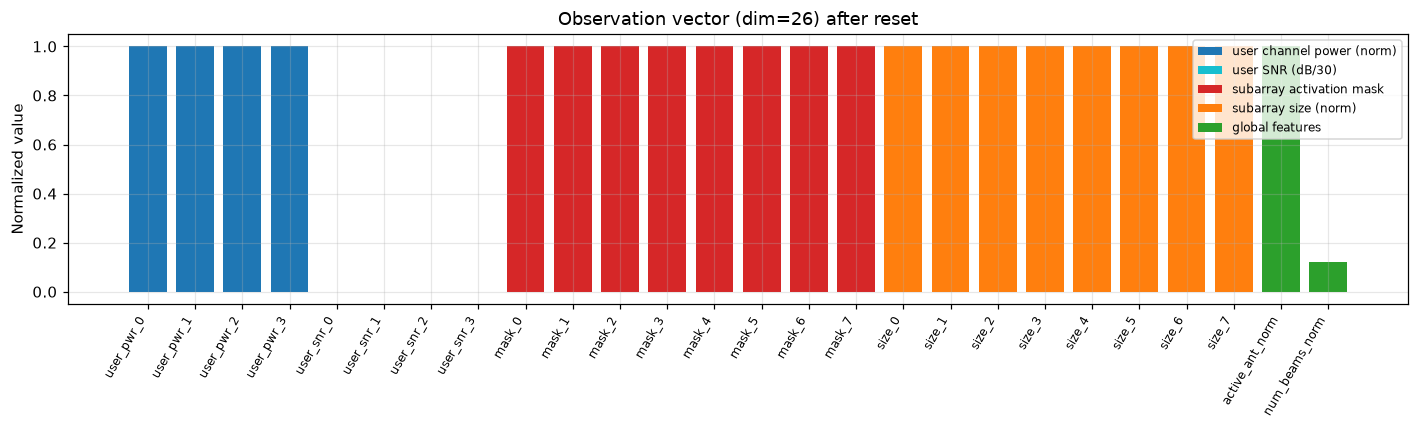

In [7]:
# %% Cell 4: FIGURE 1 - Observation vector
K_users = env.num_users
K = env.num_subarrays

labels = (
    [f"user_pwr_{i}"   for i in range(K_users)] +
    [f"user_snr_{i}"   for i in range(K_users)] +
    [f"mask_{i}"       for i in range(K)] +
    [f"size_{i}"       for i in range(K)] +
    ["active_ant_norm", "num_beams_norm"]
)

fig, ax = plt.subplots(figsize=(13, 4))
colors = (["tab:blue"] * K_users + ["tab:cyan"] * K_users +
          ["tab:red"] * K + ["tab:orange"] * K + ["tab:green"] * 2)
ax.bar(range(len(obs)), obs, color=colors)
ax.set_xticks(range(len(obs)))
ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("Normalized value")
ax.set_title(f"Observation vector (dim={len(obs)}) after reset")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3, axis="y")

legend_elems = [
    Patch(facecolor="tab:blue",   label="user channel power (norm)"),
    Patch(facecolor="tab:cyan",   label="user SNR (dB/30)"),
    Patch(facecolor="tab:red",    label="subarray activation mask"),
    Patch(facecolor="tab:orange", label="subarray size (norm)"),
    Patch(facecolor="tab:green",  label="global features"),
]
ax.legend(handles=legend_elems, loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "env_01_observation.png"))
plt.show()

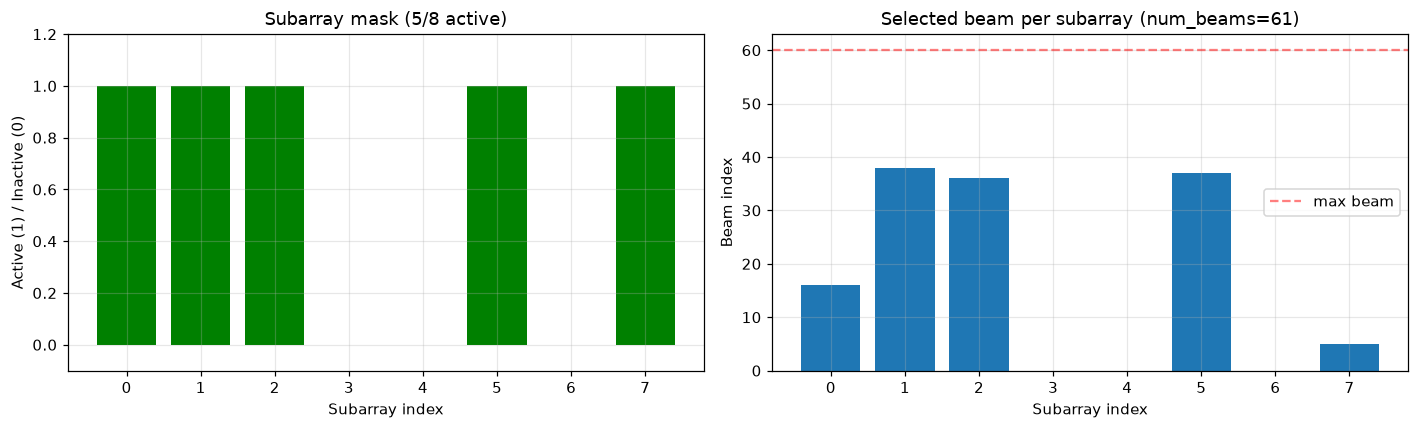

Action sample:
  mask:  [1 1 1 0 0 1 0 1]
  beams: [16 38 36 25 35 37 13  5]


In [8]:
# %% Cell 5: FIGURE 2 - Sample action
# Take a random action and visualize the mask + beam choices
env = envs["default"]
obs, _ = env.reset(seed=42)
action = env.action_space.sample()

mask  = action["subarray_mask"]
beams = action["beam_indices"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: mask
axes[0].bar(range(K), mask, color=["green" if m else "lightgray" for m in mask])
axes[0].set_xticks(range(K))
axes[0].set_xlabel("Subarray index")
axes[0].set_ylabel("Active (1) / Inactive (0)")
axes[0].set_title(f"Subarray mask ({int(mask.sum())}/{K} active)")
axes[0].set_ylim(-0.1, 1.2)

# Right: beam indices (only for active)
beams_masked = [int(b) if m else 0 for b, m in zip(beams, mask)]
colors = ["tab:blue" if m else "lightgray" for m in mask]
axes[1].bar(range(K), beams_masked, color=colors)
axes[1].set_xticks(range(K))
axes[1].set_xlabel("Subarray index")
axes[1].set_ylabel("Beam index")
axes[1].set_title(f"Selected beam per subarray (num_beams={env.num_beams})")
axes[1].axhline(env.num_beams - 1, color="red", linestyle="--", alpha=0.5,
                label="max beam")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "env_02_action_mask.png"))
plt.show()

print(f"Action sample:")
print(f"  mask:  {mask}")
print(f"  beams: {beams}")

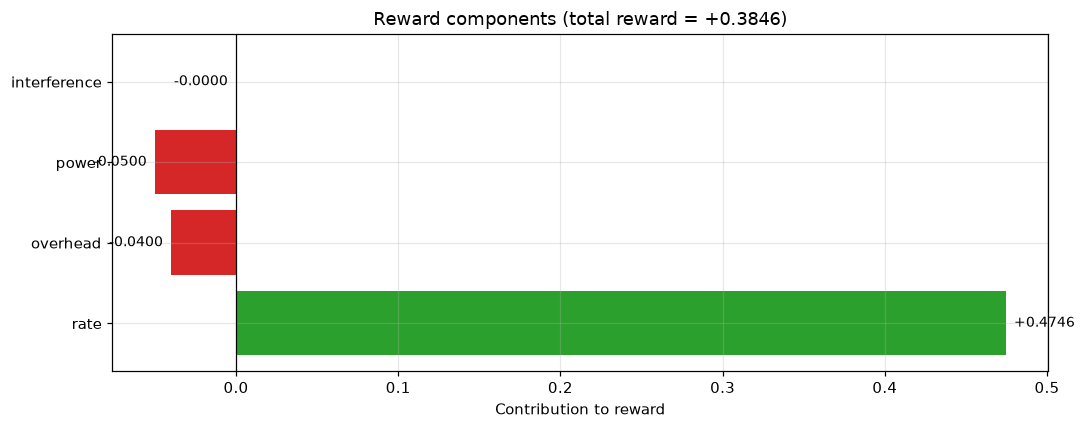

Info (subset):
  sum_rate:           23.7296 b/s/Hz
  num_active_beams:   8
  num_active_subarrays:8
  interference_power: 0.000201


In [9]:
# %% Cell 6: FIGURE 3 - Reward components
env = envs["default"]
obs, _ = env.reset(seed=42)
ref = env.get_reference_action()
_, reward, _, _, info = env.step(ref)

rc = info["reward_components"]

fig, ax = plt.subplots(figsize=(10, 4))
names  = ["rate", "overhead", "power", "interference"]
values = [rc["rate"], rc["overhead"], rc["power"], rc["interference"]]
colors = ["tab:green" if v >= 0 else "tab:red" for v in values]

bars = ax.barh(names, values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Contribution to reward")
ax.set_title(f"Reward components (total reward = {reward:+.4f})")
ax.grid(True, alpha=0.3, axis="x")

for bar, val in zip(bars, values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
            f"{val:+.4f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "env_03_reward_components.png"))
plt.show()

print(f"Info (subset):")
print(f"  sum_rate:           {info['sum_rate']:.4f} b/s/Hz")
print(f"  num_active_beams:   {info['num_active_beams']}")
print(f"  num_active_subarrays:{info['num_active_subarrays']}")
print(f"  interference_power: {info['interference_power']:.6f}")

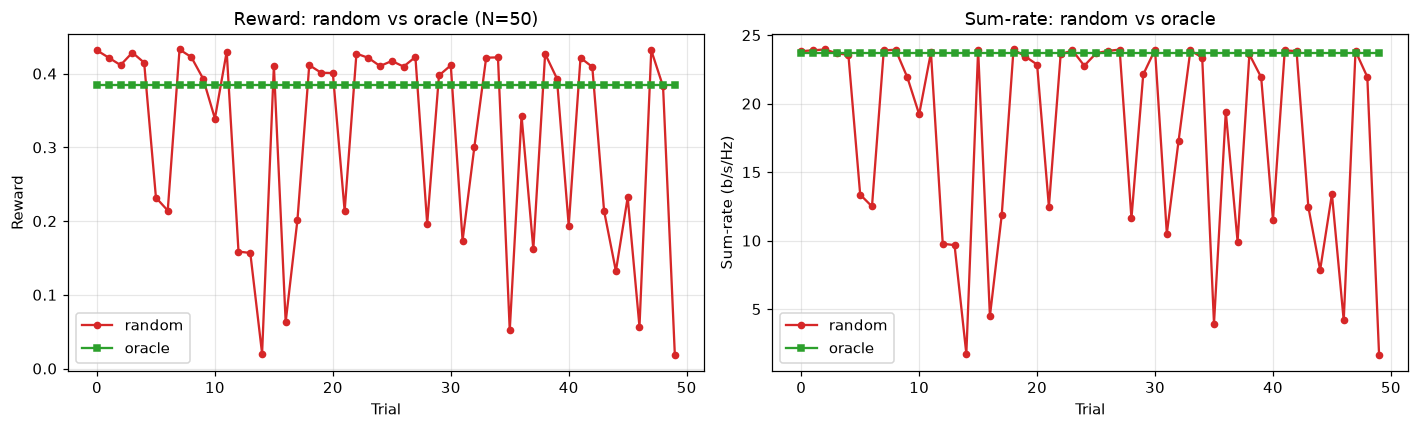

Random policy:
  mean reward:  +0.3142 (std 0.1329)
  mean rate:    17.9875 b/s/Hz
Oracle policy:
  mean reward:  +0.3846 (std 0.0000)
  mean rate:    23.7296 b/s/Hz

Oracle-vs-random reward gap: +0.0704


In [10]:
# %% Cell 7: FIGURE 4 - Random vs oracle
N_TRIALS = 50
env = envs["default"]
rng = np.random.default_rng(0)

random_rewards = []
oracle_rewards = []
random_rates = []
oracle_rates = []

for t in range(N_TRIALS):
    env.reset(seed=1000 + t)

    # Random action
    a_rand = env.action_space.sample()
    _, r_rand, _, _, info_rand = env.step(a_rand)
    random_rewards.append(r_rand)
    random_rates.append(info_rand["sum_rate"])

    # Oracle action (same env state)
    a_orc = env.get_reference_action()
    _, r_orc, _, _, info_orc = env.step(a_orc)
    oracle_rewards.append(r_orc)
    oracle_rates.append(info_orc["sum_rate"])

random_rewards = np.array(random_rewards)
oracle_rewards = np.array(oracle_rewards)
random_rates   = np.array(random_rates)
oracle_rates   = np.array(oracle_rates)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Rewards
axes[0].plot(random_rewards, "o-", color="tab:red",   label="random", markersize=4)
axes[0].plot(oracle_rewards, "s-", color="tab:green", label="oracle", markersize=4)
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Reward")
axes[0].set_title(f"Reward: random vs oracle (N={N_TRIALS})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Rates
axes[1].plot(random_rates, "o-", color="tab:red",   label="random", markersize=4)
axes[1].plot(oracle_rates, "s-", color="tab:green", label="oracle", markersize=4)
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("Sum-rate (b/s/Hz)")
axes[1].set_title("Sum-rate: random vs oracle")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "env_04_random_vs_oracle.png"))
plt.show()

print("Random policy:")
print(f"  mean reward:  {random_rewards.mean():+.4f} (std {random_rewards.std():.4f})")
print(f"  mean rate:    {random_rates.mean():.4f} b/s/Hz")
print("Oracle policy:")
print(f"  mean reward:  {oracle_rewards.mean():+.4f} (std {oracle_rewards.std():.4f})")
print(f"  mean rate:    {oracle_rates.mean():.4f} b/s/Hz")
print(f"\nOracle-vs-random reward gap: {oracle_rewards.mean() - random_rewards.mean():+.4f}")

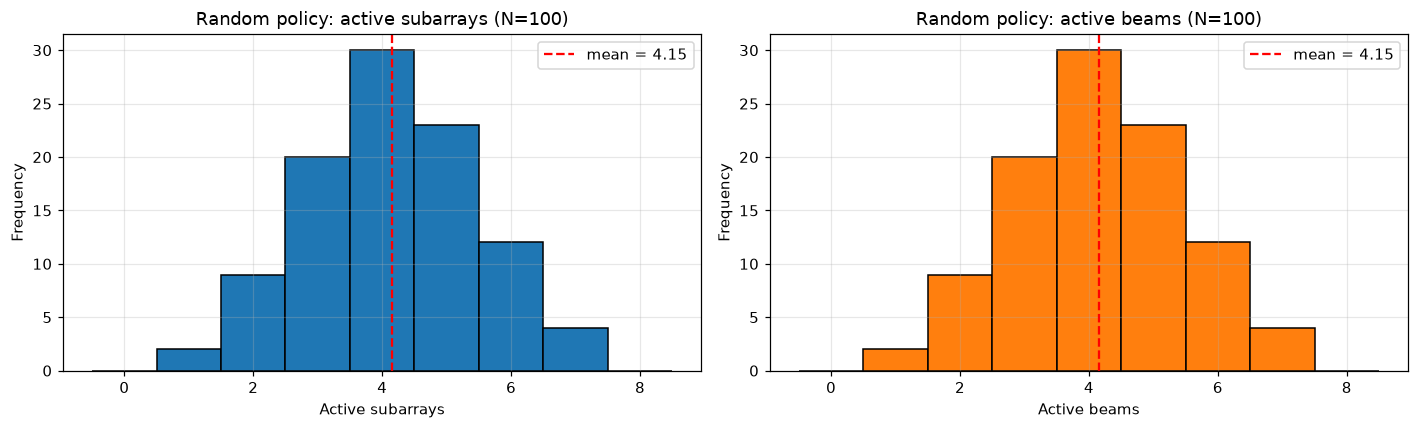

In [11]:
# %% Cell 8: FIGURE 5 - Active resources
N_STEPS = 100
env = envs["default"]
rng = np.random.default_rng(1)

active_beams_hist = []
active_subs_hist = []

for t in range(N_STEPS):
    if t % 10 == 0:
        env.reset(seed=2000 + t)
    a = env.action_space.sample()
    _, _, term, trunc, info = env.step(a)
    active_beams_hist.append(info["num_active_beams"])
    active_subs_hist.append(info["num_active_subarrays"])
    if term or trunc:
        env.reset(seed=2000 + t)

active_beams_hist = np.array(active_beams_hist)
active_subs_hist  = np.array(active_subs_hist)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(active_subs_hist, bins=range(0, env.num_subarrays + 2),
             align="left", color="tab:blue", edgecolor="black")
axes[0].set_xlabel("Active subarrays")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Random policy: active subarrays (N={N_STEPS})")
axes[0].axvline(active_subs_hist.mean(), color="red", linestyle="--",
                label=f"mean = {active_subs_hist.mean():.2f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].hist(active_beams_hist, bins=range(0, env.num_subarrays + 2),
             align="left", color="tab:orange", edgecolor="black")
axes[1].set_xlabel("Active beams")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Random policy: active beams (N={N_STEPS})")
axes[1].axvline(active_beams_hist.mean(), color="red", linestyle="--",
                label=f"mean = {active_beams_hist.mean():.2f}")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "env_05_active_resources.png"))
plt.show()

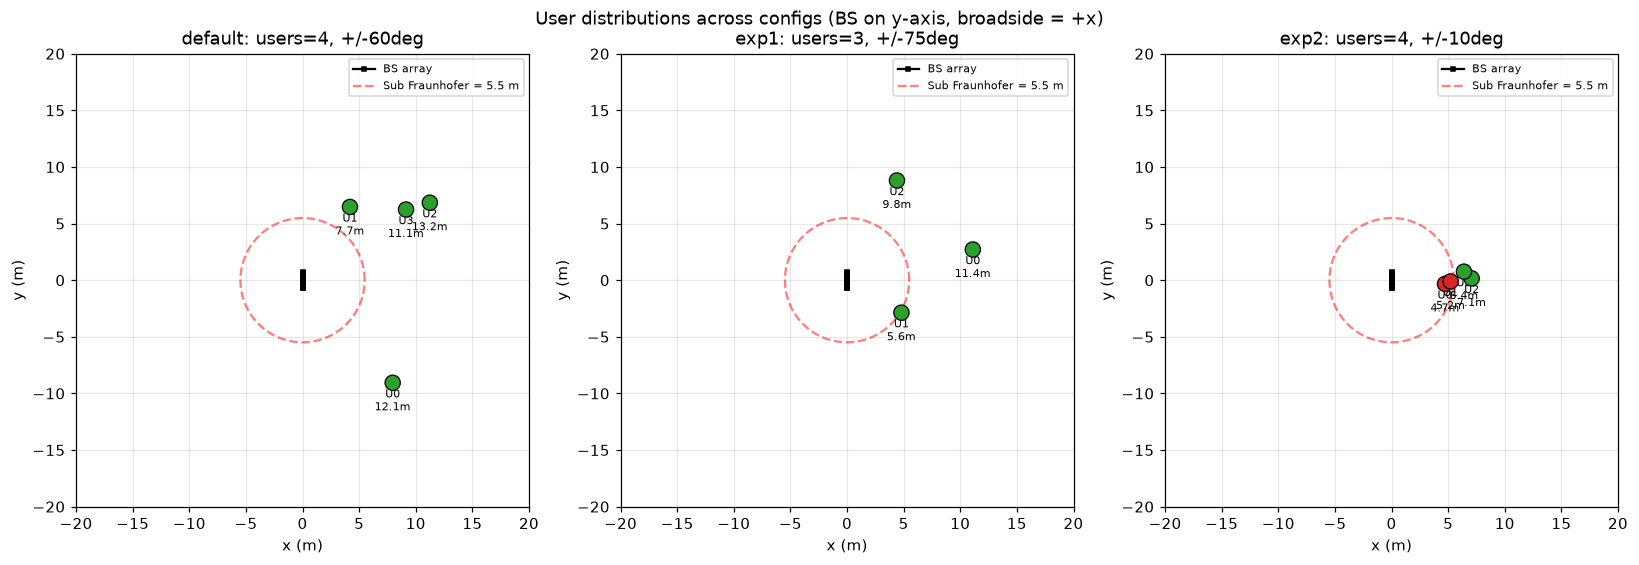

In [12]:
# %% Cell 9: FIGURE 6 - Regime map (all 3 configs)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, env) in zip(axes, envs.items()):
    # Sample several user-position realizations
    env.reset(seed=42)
    # Access underlying generator's cached positions
    positions = env.channel_gen._user_positions
    if positions is None:
        positions = env.channel_gen.generate_user_positions()

    # Compute regime for each user
    D_f_sub = 2 * (env.antennas_per_subarray * env.sys_cfg.antenna_spacing *
                   (3e8 / env.sys_cfg.carrier_frequency)) ** 2 / (
                       3e8 / env.sys_cfg.carrier_frequency)
    users_x = positions[:, 0]
    users_y = positions[:, 1]
    dists = np.linalg.norm(positions, axis=1)

    # Plot BS array (vertical line, x=0, y from -aperture/2 to +aperture/2)
    array_y = np.linspace(-env.num_antennas * env.sys_cfg.antenna_spacing *
                          (3e8 / env.sys_cfg.carrier_frequency) / 2,
                          env.num_antennas * env.sys_cfg.antenna_spacing *
                          (3e8 / env.sys_cfg.carrier_frequency) / 2, 50)
    ax.plot(np.zeros_like(array_y), array_y, "ks-", markersize=3,
            label="BS array", zorder=5)

    # Fraunhofer circle
    theta = np.linspace(0, 2 * np.pi, 100)
    ax.plot(D_f_sub * np.cos(theta), D_f_sub * np.sin(theta),
            "r--", alpha=0.5, label=f"Sub Fraunhofer = {D_f_sub:.1f} m")

    # Users
    colors = ["tab:green" if d > D_f_sub else "tab:red" for d in dists]
    ax.scatter(users_x, users_y, c=colors, s=100, zorder=6,
               edgecolor="black", linewidth=0.8)

    for i, (x, y, d) in enumerate(zip(users_x, users_y, dists)):
        ax.annotate(f"U{i}\n{d:.1f}m", (x, y), fontsize=7,
                    ha="center", va="center",
                    xytext=(0, -12), textcoords="offset points")

    ax.set_xlim(-20, 20)
    ax.set_ylim(-20, 20)
    ax.set_aspect("equal")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_title(f"{name}: users={env.num_users}, +/-{env.sys_cfg.user_angle_max_deg:.0f}deg")
    ax.legend(loc="upper right", fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle("User distributions across configs (BS on y-axis, broadside = +x)",
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "env_06_regime_check.png"))
plt.show()

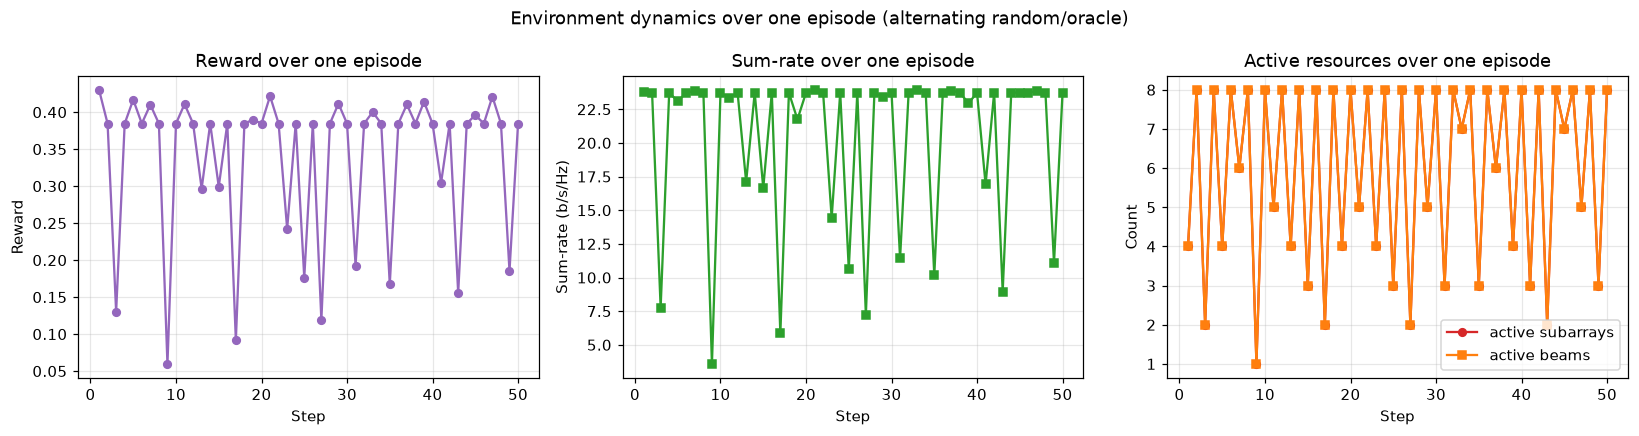

In [13]:
# %% Cell 10: FIGURE 7 - Step dynamics over one episode
env = envs["default"]
obs, _ = env.reset(seed=42)

rewards_ep = []
rates_ep   = []
beams_ep   = []
subs_ep    = []

for t in range(env.cfg.training.max_steps_per_episode):
    # Alternate random and oracle to make the trajectory interesting
    if t % 2 == 0:
        a = env.action_space.sample()
    else:
        a = env.get_reference_action()
    _, r, term, trunc, info = env.step(a)
    rewards_ep.append(r)
    rates_ep.append(info["sum_rate"])
    beams_ep.append(info["num_active_beams"])
    subs_ep.append(info["num_active_subarrays"])
    if term or trunc:
        break

steps = np.arange(1, len(rewards_ep) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(steps, rewards_ep, "o-", color="tab:purple", markersize=5)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Reward")
axes[0].set_title("Reward over one episode")
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, rates_ep, "s-", color="tab:green", markersize=5)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Sum-rate (b/s/Hz)")
axes[1].set_title("Sum-rate over one episode")
axes[1].grid(True, alpha=0.3)

axes[2].plot(steps, subs_ep, "o-", label="active subarrays",
             color="tab:red", markersize=5)
axes[2].plot(steps, beams_ep, "s-", label="active beams",
             color="tab:orange", markersize=5)
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Count")
axes[2].set_title("Active resources over one episode")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("Environment dynamics over one episode (alternating random/oracle)",
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "env_07_step_dynamics.png"))
plt.show()

Environment Validation Summary (3 configs x 30 random trials)

[default]
  reward:    +0.2970 (+/- 0.1432)
  rate:      17.0841 b/s/Hz
  subarrays: 3.87 (out of 8)
  beams:     3.87

[exp1]
  reward:    +0.1922 (+/- 0.0630)
  rate:      19.1927 b/s/Hz
  subarrays: 4.03 (out of 8)
  beams:     4.03

[exp2]
  reward:    +0.2999 (+/- 0.1507)
  rate:      16.7433 b/s/Hz
  subarrays: 3.77 (out of 8)
  beams:     3.77


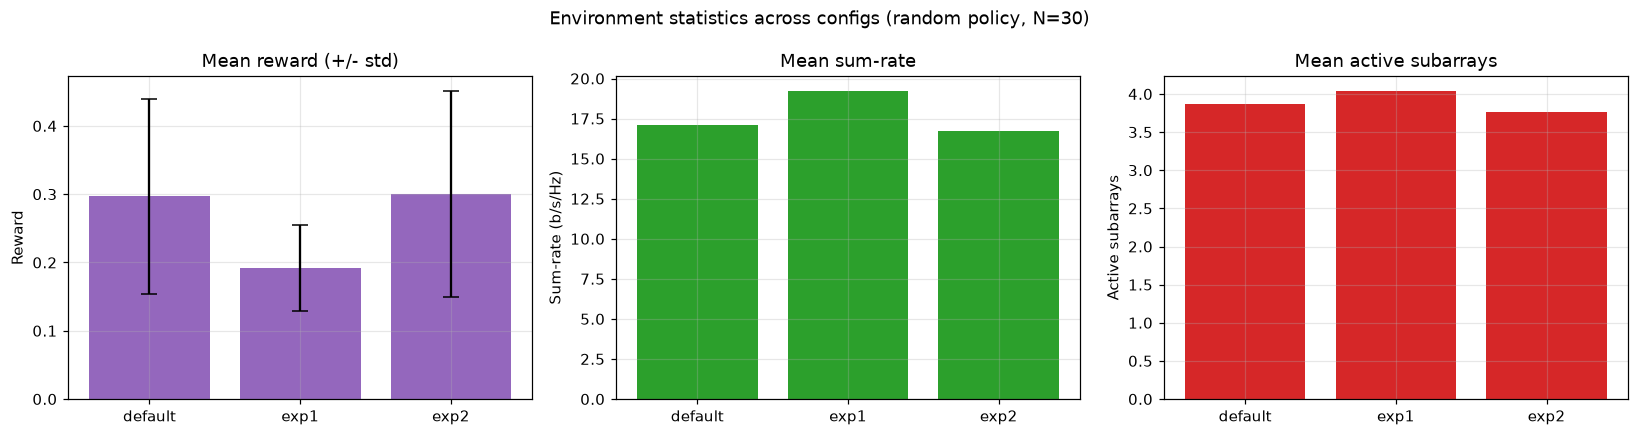


Environment testing complete.


In [14]:
# %% Cell 11: Multi-config validation
print("=" * 70)
print("Environment Validation Summary (3 configs x 30 random trials)")
print("=" * 70)

N_TRIALS = 30
summary = {}

for name, env in envs.items():
    rewards = []
    rates   = []
    subs    = []
    beams   = []

    for t in range(N_TRIALS):
        env.reset(seed=5000 + t)
        a = env.action_space.sample()
        _, r, _, _, info = env.step(a)
        rewards.append(r)
        rates.append(info["sum_rate"])
        subs.append(info["num_active_subarrays"])
        beams.append(info["num_active_beams"])

    summary[name] = {
        "reward_mean": float(np.mean(rewards)),
        "reward_std":  float(np.std(rewards)),
        "rate_mean":   float(np.mean(rates)),
        "subs_mean":   float(np.mean(subs)),
        "beams_mean":  float(np.mean(beams)),
    }

    print(f"\n[{name}]")
    print(f"  reward:    {summary[name]['reward_mean']:+.4f} "
          f"(+/- {summary[name]['reward_std']:.4f})")
    print(f"  rate:      {summary[name]['rate_mean']:.4f} b/s/Hz")
    print(f"  subarrays: {summary[name]['subs_mean']:.2f} (out of {env.num_subarrays})")
    print(f"  beams:     {summary[name]['beams_mean']:.2f}")

# Comparison figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = list(summary.keys())
xs = np.arange(len(names))

axes[0].bar(xs, [summary[n]["reward_mean"] for n in names],
            yerr=[summary[n]["reward_std"] for n in names],
            color="tab:purple", capsize=5)
axes[0].set_xticks(xs); axes[0].set_xticklabels(names)
axes[0].set_ylabel("Reward")
axes[0].set_title("Mean reward (+/- std)")

axes[1].bar(xs, [summary[n]["rate_mean"] for n in names],
            color="tab:green", capsize=5)
axes[1].set_xticks(xs); axes[1].set_xticklabels(names)
axes[1].set_ylabel("Sum-rate (b/s/Hz)")
axes[1].set_title("Mean sum-rate")

axes[2].bar(xs, [summary[n]["subs_mean"] for n in names],
            color="tab:red", capsize=5)
axes[2].set_xticks(xs); axes[2].set_xticklabels(names)
axes[2].set_ylabel("Active subarrays")
axes[2].set_title("Mean active subarrays")

plt.suptitle("Environment statistics across configs (random policy, N=30)",
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "env_08_config_comparison.png"))
plt.show()

# ASCII-only final message
print("\n" + "=" * 70)
print("Environment testing complete.")
print("=" * 70)